### Цель исследования:


Цель данного проекта — Проанализировать рынок вин на основе данных об оценках и ценах, учитывая региональные особенности (Старый и Новый свет).
Для анализа используется набор данных из Kaggle (профессиональное сообщество специалистов по обработке данных и машинному обучению).
https://www.kaggle.com/datasets/zynicide/wine-reviews?resource=download

### Столбцы данных
country — страна происхождения вина<br>
description — текстовое описание вина (вкус, аромат, характеристики)<br>
designation — название виноградника или участка, откуда происходит виноград для этого вина<br>
points — оценка, которую журнал WineEnthusiast поставил вину по шкале от 1 до 100 (обычно публикуются только оценки ≥ 80)<br>
price — цена за одну бутылку вина<br>
province — провинция или штат, в котором произведено вино<br>
region_1 — винодельческий регион внутри провинции / штата<br>
region_2 — более узкий подрегион внутри винодельческой зоны (может быть пустым)<br>
taster_name — имя дегустатора, который оценивал вино<br>
taster_twitter_handle — аккаунт дегустатора в Twitter (если указан)<br>
title — полное название вина (включает название, сорт, год)<br>
variety — сорт винограда, из которого сделано вино<br>
winery — название винодельни (производителя)<br>
age — сегментация, добавленная в ходе анализа: "new" (Новый свет) или "old" (Старый свет)

#  <a name="1">1.Предобработка данных</a>

### Импорт необходимых библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
sns.set_style("darkgrid")
plt.style.use('ggplot')
%matplotlib inline
import scipy.stats as st
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Загрузка данных

In [53]:
df = pd.read_csv('wine_reviews.csv')
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


* Столбцы названы корректно, замена не нужна.

### Удаление дубликатов

In [54]:
print(df.shape)
print(df.duplicated().sum())

(129971, 14)
0


In [55]:
df = df.drop_duplicates().reset_index(drop=True) 

In [56]:
print(df.shape)
print(df.duplicated().sum())

(129971, 14)
0


In [57]:
print(df['country'].dropna().unique().tolist())

['Italy', 'Portugal', 'US', 'Spain', 'France', 'Germany', 'Argentina', 'Chile', 'Australia', 'Austria', 'South Africa', 'New Zealand', 'Israel', 'Hungary', 'Greece', 'Romania', 'Mexico', 'Canada', 'Turkey', 'Czech Republic', 'Slovenia', 'Luxembourg', 'Croatia', 'Georgia', 'Uruguay', 'England', 'Lebanon', 'Serbia', 'Brazil', 'Moldova', 'Morocco', 'Peru', 'India', 'Bulgaria', 'Cyprus', 'Armenia', 'Switzerland', 'Bosnia and Herzegovina', 'Ukraine', 'Slovakia', 'Macedonia', 'China', 'Egypt']


In [58]:
df['variety'] = df['variety'].str.lower()

### Проверка типов данных

In [59]:
df.dtypes

Unnamed: 0                 int64
country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object

* Типы данных в столбцах соответствуют содержимому, заменять не нужно.

### Обработка пропусков

In [60]:
MissingValue = df.isnull().sum().sort_values(ascending = False)
Percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False).round(2)
MissingData = pd.concat([MissingValue, Percent], axis=1, keys=['Пропущенные значения', 'Процент'])
MissingData

,Пропущенные значения,Процент
region_2,79460,61.14
designation,37465,28.83
taster_twitter_handle,31213,24.02
taster_name,26244,20.19
region_1,21247,16.35
price,8996,6.92
country,63,0.05
province,63,0.05
variety,1,0.00
Unnamed: 0,0,0.00


* Удаляем строки, где нет страны и цены

In [61]:
df = df.dropna(subset=['country','price', 'variety'])

In [62]:
MissingValue = df.isnull().sum().sort_values(ascending = False)
Percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False).round(2)
MissingData = pd.concat([MissingValue, Percent], axis=1, keys=['Пропущенные значения', 'Процент'])
MissingData

,Пропущенные значения,Процент
region_2,70623,58.41
designation,34767,28.75
taster_twitter_handle,29415,24.33
taster_name,24495,20.26
region_1,19515,16.14
Unnamed: 0,0,0.00
country,0,0.00
description,0,0.00
points,0,0.00
price,0,0.00


* Пропуски в столбцах designation, price, region_1, region_2.

In [63]:
countries = df.groupby(by='country').count()[['province','region_1', 'region_2', 'designation']].sort_values(by='province', ascending=False)
countries.head(15)

,province,region_1,region_2,designation
country,,,,
US,54265,53989,50292,36751
France,17776,17708,0,11840
Italy,16914,16889,0,11993
Spain,6573,6565,0,5257
Portugal,4875,0,0,4381
Chile,4415,0,0,3825
Argentina,3756,3703,0,2863
Austria,2799,0,0,2370
Australia,2294,2292,0,1618


* Данные по региону 1 есть всего для 7 стран, их можно учитывать для анализа данных по этим странам. Удалять или заменять нецелесообразно.
* Данные по региону 2 есть только для США, столбец можно сохранить для анализа данных по этой стране.
* Данные по происхождению designation отсутствуют равномерно для всех стран.

In [65]:
countries = df.groupby(df['variety']).count()['province'].sort_values(ascending=False)
countries.head(10)

variety
pinot noir                  12785
chardonnay                  11077
cabernet sauvignon           9384
red blend                    8466
bordeaux-style red blend     5340
riesling                     4971
sauvignon blanc              4780
syrah                        4086
rosé                         3261
merlot                       3061
Name: province, dtype: int64

* Riserva, Reserva или Reserve наиболее часто встречается на бутылках. Это один тот же термин, но в разных странах, у разных производителей может означать разное. Использование не регламентировано. В столбце много дублей, но объединять их на этом этапе не будем, а польза от информации не очевидна, пока оставим как есть.

In [13]:
df.describe().round(2)

,Unnamed: 0,points,price
count,120915.00,120915.00,120915.00
mean,65043.61,88.42,35.37
std,37511.73,3.04,41.03
min,1.00,80.00,4.00
25%,32571.50,86.00,17.00
50%,65141.00,88.00,25.00
75%,97501.50,91.00,42.00
max,129970.00,100.00,3300.00


* Вина оценены в пунктах от 80 до 100 баллов. Средняя оценка 88.
* Цены вин от 4 до 3300. Средняя цена 35 сильно сдвинута вправо относительно медианы 25, что говорит о наличии значимого количества премиальных вин.
* Поскольку в данных есть премиальные вина, то замена пропусков на среднее даст некорректный результат. Нужно либо удалять эти строки, либо искать способ адекватной замены значений. Будет зависить от задачи анализа. Пока оставим как есть.

### Добавление информации (столбцов)

In [14]:
df.describe(include=['O']).T

,count,unique,top,freq
country,120915,42,US,54265
description,120915,111511,"Ripe plum, game, truffle, leather and menthol ...",3
designation,86148,35753,Reserve,1977
province,120915,422,California,36104
region_1,101400,1204,Napa Valley,4475
region_2,50292,17,Central Coast,10975
taster_name,96420,19,Roger Voss,20172
taster_twitter_handle,91500,15,@vossroger,20172
title,120915,110582,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,11
variety,120915,691,Pinot Noir,12785


* В наборе данные 42 стран и почти 16 тысяч виноделен. Лидер по количеству представленных для оценки вин США, почти 45% от всех наименований. 80% всех представленных вин были оценены всего 19 тестировщиками.

In [15]:
from IPython.display import Image
Image(url='https://fortwine.ru/upload/medialibrary/787/7871f58b49b88d3fbc7e2e4efdd0ec70.jpg')

* По данным  OIV (Международная организация виноградарства и виноделия) на 2017 год доля США в объемах производства всего 9.3%, что соответствует только четвертому номеру в рейтинге. Топ-3 страны по производству вина европейские, их суммарная доля состявляет 44.5%.
* Имеет смысл смотреть на рынок так, как его видят сами игроки. Традиционно рынок делится на производителей Старого и Нового света. Под винами Старого Света понимаются главным образом вина из пяти стран, до середины XX века задававших тон в области виноделия: Франции, Италии, Германии, Испании и Португалии. Понятие Нового Света не совпадает с традиционным, ибо подразумевает все страны без сложившихся столетиями традиций и технологий виноградного виноделия. Обычно сюда относят вина из Аргентины, Чили, Уругвая, Австралии, Новой Зеландии, ЮАР, США и Канады.
* Такой подход, позволит также ответить на вопрос о причинах разницы между долями в номенклатуре винной продукции и объемах производства.

In [16]:
age = {
 # Старый свет (классический)
    "France": "old",
    "Italy": "old",
    "Spain": "old",
    "Portugal": "old",
    "Germany": "old",
    "Austria": "old",
    "Greece": "old",
    "Hungary": "old"
}

df['age'] = df['country'].map(age).fillna('new')

old_new = df[['country', 'points', 'price', 'province', 'variety', 'winery', 'age']]
old_new.head()

,country,points,price,province,variety,winery,age
1,Portugal,87,15.0,Douro,Portuguese Red,Quinta dos Avidagos,old
2,US,87,14.0,Oregon,Pinot Gris,Rainstorm,new
3,US,87,13.0,Michigan,Riesling,St. Julian,new
4,US,87,65.0,Oregon,Pinot Noir,Sweet Cheeks,new
5,Spain,87,15.0,Northern Spain,Tempranillo-Merlot,Tandem,old


In [17]:
old_new.isnull().sum()

country     0
points      0
price       0
province    0
variety     0
winery      0
age         0
dtype: int64

* В таблицу добавлена категоризация Новый/Старый свет.

#  <a name="2"> 2. Исследовательский анализ данных</a>


In [88]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 120915 entries, 1 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             120915 non-null  int64  
 1   country                120915 non-null  object 
 2   description            120915 non-null  object 
 3   designation            86148 non-null   object 
 4   points                 120915 non-null  int64  
 5   price                  120915 non-null  float64
 6   province               120915 non-null  object 
 7   region_1               101400 non-null  object 
 8   region_2               50292 non-null   object 
 9   taster_name            96420 non-null   object 
 10  taster_twitter_handle  91500 non-null   object 
 11  title                  120915 non-null  object 
 12  variety                120915 non-null  object 
 13  winery                 120915 non-null  object 
dtypes: float64(1), int64(2), object(11)
memor

In [19]:
old_new.describe(include=['O']).T

,count,unique,top,freq
country,120915,42,US,54265
province,120915,422,California,36104
variety,120915,691,Pinot Noir,12785
winery,120915,15843,Testarossa,217
age,120915,2,new,69252


* В таблице содержатся данные тестирования вин из разнличных стран.
* cидирующая страна - США
* самый распростаненный сорт винограда - Pinot Noir
* самый большой портфель у винодельни Testarossa

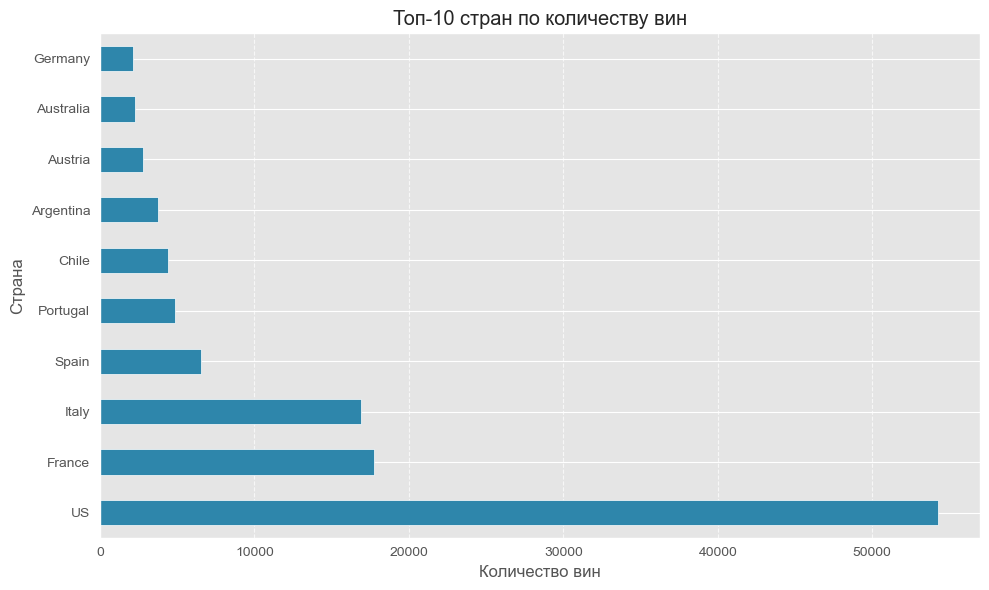

In [71]:
# ТОП-10 стран ко количеству сортов
segm_country = df['country'].value_counts().head(10)

# График
plt.figure(figsize=(10, 6))
segm_country.plot(kind='barh', color='#2E86AB', edgecolor='white')
plt.xlabel('Количество вин')
plt.ylabel('Страна')
plt.title('Топ-10 стран по количеству вин')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* Лидер по представленности в данных - вина США. За США идут страны Старого света: Франция, Италия, Испания, Португалия.

In [83]:
print(df.describe().round(1))

       Unnamed: 0    points     price
count    120915.0  120915.0  120915.0
mean      65043.6      88.4      35.4
std       37511.7       3.0      41.0
min           1.0      80.0       4.0
25%       32571.5      86.0      17.0
50%       65141.0      88.0      25.0
75%       97501.5      91.0      42.0
max      129970.0     100.0    3300.0


* Вина имеют оценку от 80 до 100 пунктов, средняя оценка вин - 88 пунктов.
* Представленные вина стоят от 4 до 3300 долларов, средняя цена - 35 долларов. Нужно проверить на выбросы в данных.

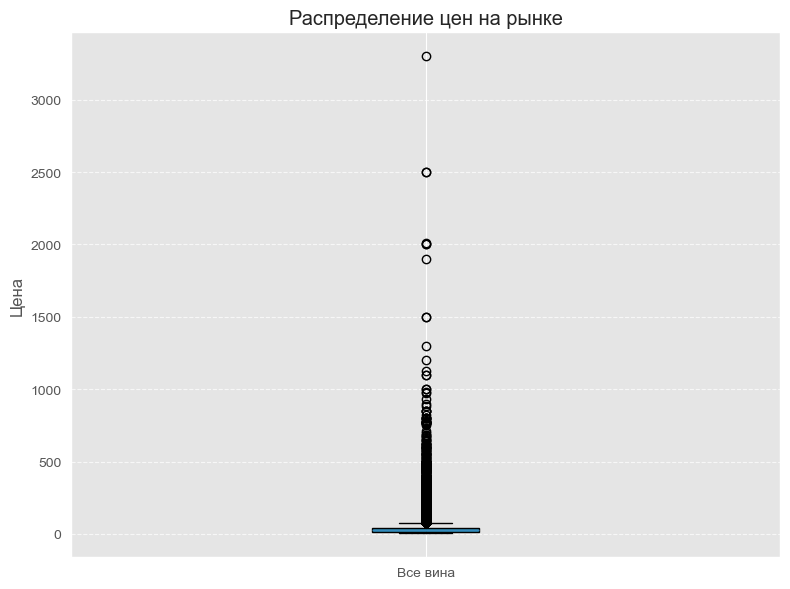

In [79]:
# Распределение цен
plt.figure(figsize=(8, 6))
plt.boxplot(df['price'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#2E86AB'))
plt.title('Распределение цен на рынке')
plt.ylabel('Цена')
plt.xticks([1], ['Все вина'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* Судя по графику, вин, имеющих цену значительно выше основной массы, достаточное количество, чтобы объединить их в суперпремиальный сегмент, который нужно анализировать отдельно.

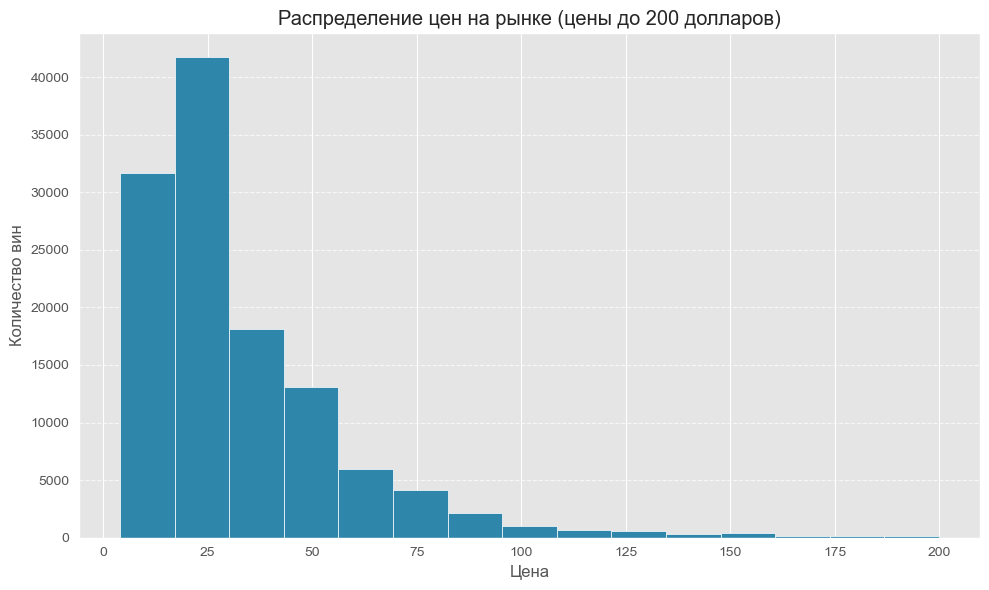

In [96]:
# Распределение цен (до 200)
price_filtered = df[df['price'] <= 200]

plt.figure(figsize=(10, 6))
plt.hist(price_filtered['price'].dropna(), bins=15, color='#2E86AB', edgecolor='white')
plt.xlabel('Цена')
plt.ylabel('Количество вин')
plt.title('Распределение цен на рынке (цены до 200 долларов)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* Распределение цен имеет правостороннюю асимметрию (длинный хвост в сторону дорогих вин). Основная масса вин сосредоточена в диапазоне 17-42 доллара, а редкие дорогие позиции (до 200+) формируют длинный хвост, в котором видны ценовые разрывы.

### Регионы

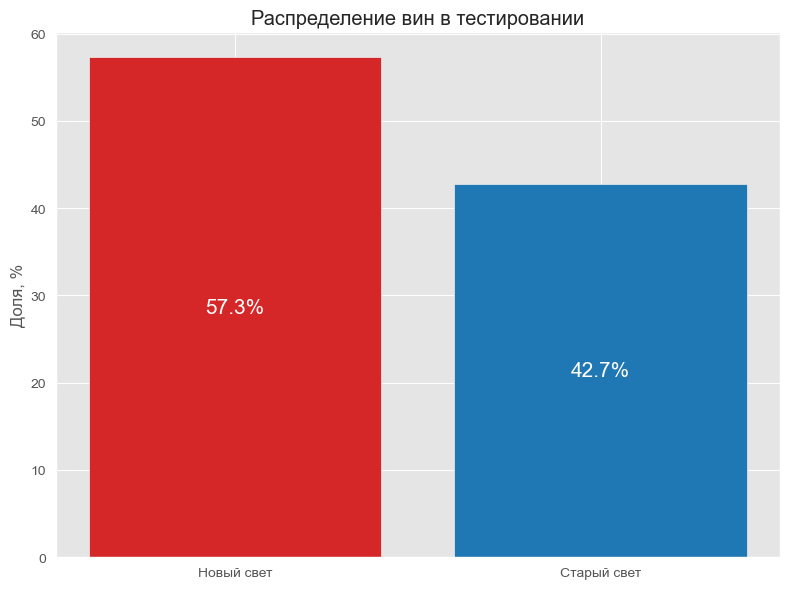

In [66]:
plt.close('all')

# Данные
counts = old_new['age'].value_counts()
percentages = counts / counts.sum() * 100

labels = ['Новый свет', 'Старый свет']
colors = ['#d62728', '#1f77b4']

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, percentages, color=colors)
ax.set_ylabel('Доля, %')
ax.set_title('Распределение вин в тестировании')

# Подписи над столбцами
ax.text(0, percentages['new'] / 2, f'{percentages["new"]:.1f}%', ha='center', va='center', fontsize=15, color='white')
ax.text(1, percentages['old'] / 2, f'{percentages["old"]:.1f}%', ha='center', va='center', fontsize=15, color='white')

plt.tight_layout()
plt.show()

* Новый свет производит больше наименований.

In [24]:
old_world = old_new[old_new.age == 'old']
new_world = old_new[old_new.age == 'new']

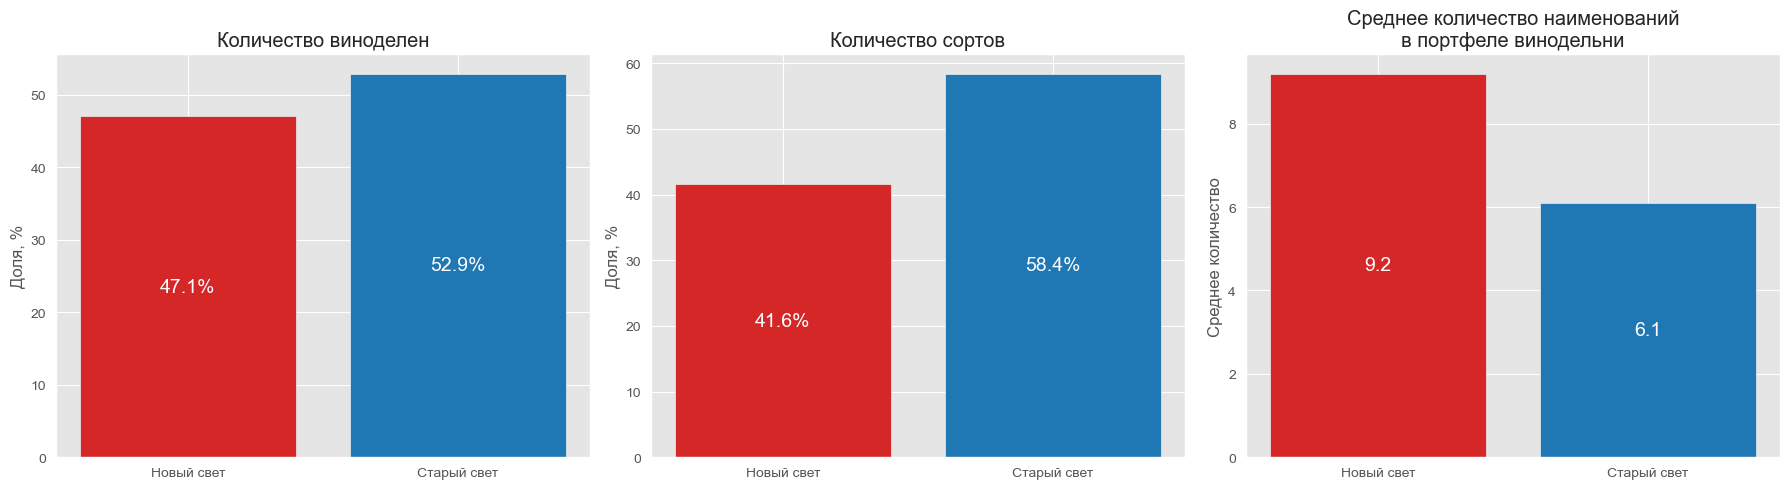

Таблица данных:
        Группа  Винодельни (уникальные)  Сорта (уникальные)  \
0   Новый свет                     7487                 367   
1  Старый свет                     8417                 516   

   Винодельни (доля, %)  Сорта (доля, %)  Среднее в портфеле  
0                  47.1             41.6                 9.2  
1                  52.9             58.4                 6.1  


In [99]:
import matplotlib.pyplot as plt
import pandas as pd

plt.close('all')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#d62728', '#1f77b4']
labels = ['Новый свет', 'Старый свет']

# ------ График 1: Винодельни (проценты) ------
winery_counts = old_new.groupby('age')[['winery']].nunique()
winery_pct = winery_counts / winery_counts.sum() * 100
bars1 = axes[0].bar(labels, winery_pct['winery'], color=colors)
axes[0].set_title('Количество виноделен')
axes[0].set_ylabel('Доля, %')
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height/2,
                 f'{height:.1f}%', ha='center', va='center', color='white', fontsize=14)

# ------ График 2: Сорта (проценты) ------
variety_counts = old_new.groupby('age')[['variety']].nunique()
variety_pct = variety_counts / variety_counts.sum() * 100
bars2 = axes[1].bar(labels, variety_pct['variety'], color=colors)
axes[1].set_title('Количество сортов')
axes[1].set_ylabel('Доля, %')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height/2,
                 f'{height:.1f}%', ha='center', va='center', color='white', fontsize=14)

# ------ График 3: Среднее количество в портфеле ------
compar_2 = old_world['winery'].value_counts().mean().round(1)
compar_3 = new_world['winery'].value_counts().mean().round(1)
values = [compar_3, compar_2]
bars3 = axes[2].bar(labels, values, color=colors)
axes[2].set_title('Среднее количество наименований\nв портфеле винодельни')
axes[2].set_ylabel('Среднее количество')
for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height/2,
                 f'{height:.1f}', ha='center', va='center', color='white', fontsize=14)

plt.tight_layout()
plt.show()

# ------ Общая таблица ------
print('Таблица данных:')
table_data = pd.DataFrame({
    'Группа': ['Новый свет', 'Старый свет'],
    'Винодельни (уникальные)': winery_counts['winery'].values,
    'Сорта (уникальные)': variety_counts['variety'].values,
    'Винодельни (доля, %)': winery_pct['winery'].values.round(1),
    'Сорта (доля, %)': variety_pct['variety'].values.round(1),
    'Среднее в портфеле': values
})
print(table_data)

* Однако в Старом свете на 12% больше виноделен чем в Новом свете и на 40% больше различных сортов винограда.
* В Новом свете на 50% больше разнычных наименований в портфеле производителя.

* Итого: производителей Нового света меньше, их портфели крупнее, но общее число различных вин значительно меньше. Это говорит об ориентации производителей Нового света на проверенные рынком наименования, чем на разработку уникальных сортов.

### Сорта винограда

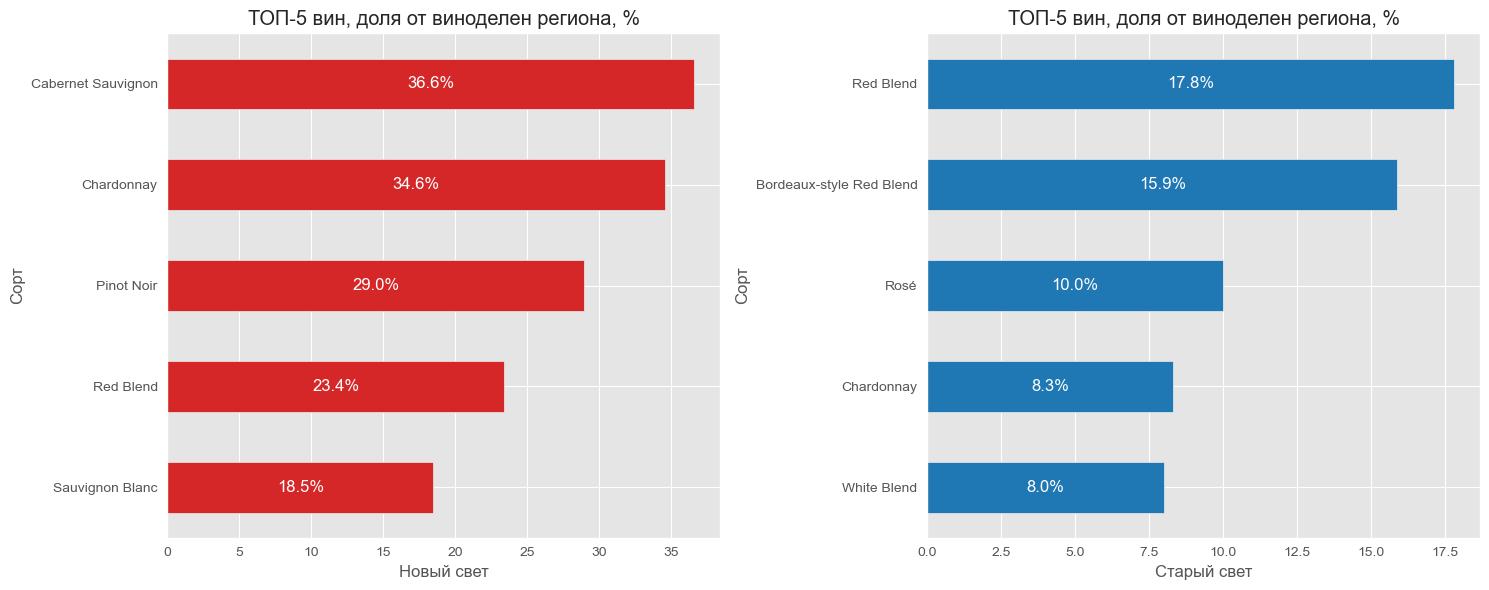

Таблица данных:
Новый свет:
                    winery  percent
variety                            
Sauvignon Blanc       1384     18.5
Red Blend             1755     23.4
Pinot Noir            2170     29.0
Chardonnay            2594     34.6
Cabernet Sauvignon    2737     36.6

Старый свет:
                          winery  percent
variety                                  
White Blend                  671      8.0
Chardonnay                   696      8.3
Rosé                         845     10.0
Bordeaux-style Red Blend    1340     15.9
Red Blend                   1500     17.8


In [27]:
# Топ-5 для Нового света (с процентом)
new_total = new_world['winery'].nunique()
new_top5 = new_world.groupby('variety')[['winery']].nunique().sort_values(by='winery', ascending=False).head(5)
new_top5['percent'] = (new_top5['winery'] / new_total * 100).round(1)
new_top5 = new_top5.sort_values(by='percent', ascending=True)

# Топ-5 для Старого света (с процентом)
old_total = old_world['winery'].nunique()
old_top5 = old_world.groupby('variety')[['winery']].nunique().sort_values(by='winery', ascending=False).head(5)
old_top5['percent'] = (old_top5['winery'] / old_total * 100).round(1)
old_top5 = old_top5.sort_values(by='percent', ascending=True)

# Создаём фигуру
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График Нового света
new_top5['percent'].plot(kind='barh', ax=axes[0], color='#d62728', legend=False)
axes[0].set_title('ТОП-5 вин, доля от виноделен региона, %')
axes[0].set_xlabel('Новый свет')
axes[0].set_ylabel('Сорт')

# Подписи на барах (Новый свет)
for bar in axes[0].patches:
    width = bar.get_width()
    axes[0].text(width / 2, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}%', ha='center', va='center',
                 color='white', fontsize=12)

# График Старого света
old_top5['percent'].plot(kind='barh', ax=axes[1], color='#1f77b4', legend=False)
axes[1].set_title('ТОП-5 вин, доля от виноделен региона, %')
axes[1].set_xlabel('Старый свет')
axes[1].set_ylabel('Сорт')

# Подписи на барах (Старый свет)
for bar in axes[1].patches:
    width = bar.get_width()
    axes[1].text(width / 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.show()

print('Таблица данных:')
print('Новый свет:')
print(new_top5[['winery', 'percent']])
print('\nСтарый свет:')
print(old_top5[['winery', 'percent']])

* Портфели производителей Нового света однороднее. Сорта - лидеры по количеству виноделен их выпускающих отличаются в Старом и Новом свете. В Старом свете много локальных игроков, которые производят местные сорта.

In [28]:
# Топ-5 по рейтингу в Новом свете
new_top5 = (new_world.groupby('variety')[['points', 'price']].median().sort_values(by='points', ascending=False).head(5).round(1).reset_index())

# Топ-5 по рейтингу в Старом свете
old_top5 = (old_world.groupby('variety')[['points', 'price']].median().sort_values(by='points', ascending=False).head(5).round(1).reset_index())

# Переименовываем колонки
new_top5.columns = ['Сорт', 'Рейтинг', 'Цена']
old_top5.columns = ['Сорт', 'Рейтинг', 'Цена']

# Добавляем уровни заголовков
new_top5.columns = pd.MultiIndex.from_tuples([('Новый свет', 'Сорт'),('Новый свет', 'Рейтинг'),('Новый свет', 'Цена')])
old_top5.columns = pd.MultiIndex.from_tuples([('Старый свет', 'Сорт'),('Старый свет', 'Рейтинг'),('Старый свет', 'Цена')])

# Объединяем
result = pd.concat([new_top5, old_top5], axis=1)

print(result)

            Новый свет                     Старый свет               
                  Сорт Рейтинг   Цена             Сорт Рейтинг   Цена
0           Muscadelle    94.0  140.0   Tinta del Pais    95.0   47.5
1       Moscato Giallo    94.0   16.0  Gelber Traminer    95.0   35.0
2  Riesling-Chardonnay    94.0   40.0        Terrantez    95.0  236.0
3   Syrah-Petit Verdot    94.0   49.0             Bual    94.5   50.0
4       Trousseau Gris    93.0   26.0          Sercial    94.0   50.0


* Топовые сорта вин Старого и нового света не совпадают
* Лучшие вина Старого света оцениваются выше
* Лучше оцененные вина не являются массово производимыми разными винодельнями

### Оценки и цены

In [82]:
old_new.describe().round(1)

,points,price
count,120915.0,120915.0
mean,88.4,35.4
std,3.0,41.0
min,80.0,4.0
25%,86.0,17.0
50%,88.0,25.0
75%,91.0,42.0
max,100.0,3300.0


     points  price
age               
new    88.0   28.0
old    88.0   24.0


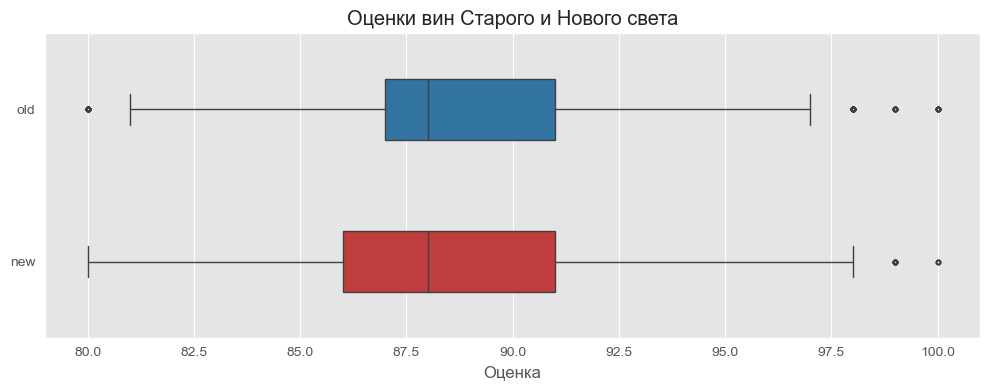

In [100]:
# Медианы (для справки, если нужно)
compar_2 = old_new.groupby('age')[['points', 'price']].median()
print(compar_2)

# График
plt.figure(figsize=(10, 4))
sns.boxplot(data=old_new, x='points', y='age', 
            width=0.4, orient='h', fliersize=3,
            palette={'new': '#d62728', 'old': '#1f77b4'})

plt.title('Оценки вин Старого и Нового света')
plt.xlabel('Оценка')
plt.ylabel('')

plt.tight_layout()
plt.show()

* Вина Старого света имеют более стабильное качество, т.к. вина с оценкой ниже среднего в основном имеют не сильно оличающуюся от среднего оценку, в отличие от вин Нового света.

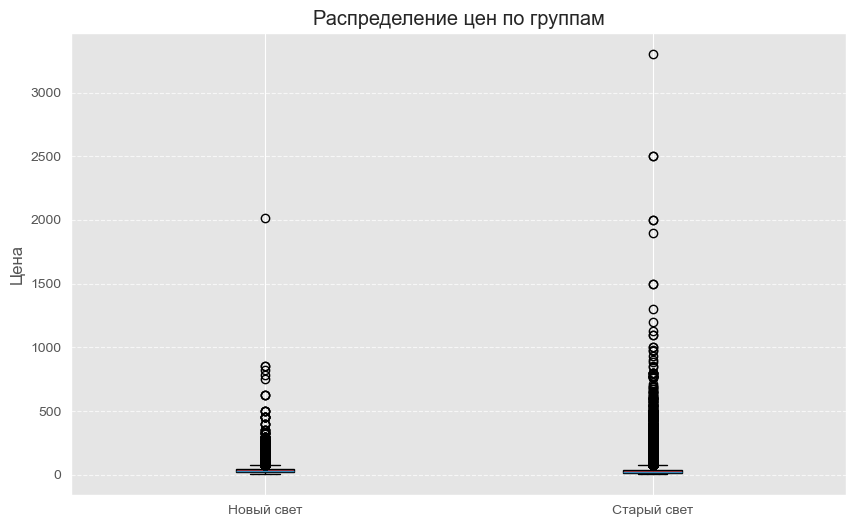

In [37]:
# Сравнительный boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(
    [new_world['price'].dropna(), old_world['price'].dropna()],
    tick_labels=['Новый свет', 'Старый свет'],
    patch_artist=True,
    boxprops=dict(facecolor='#d62728'),
    positions=[1, 2]
)
plt.title('Распределение цен по группам')
plt.ylabel('Цена')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* В Новом свете основная масса вин представленаа в сегментах до 300 долларов за бутылку и есть несколько более дорогих наименований. В Старом свете вина более дорогие, до 750 долларов основная масса и больше наименований в премиуме, это можно объяснить наличием небольших виноделен с локальными марками, позиционирующими себя дороже.
* присутствуют премиальные вина, которые искажают общую картину, их нужно смотреть отдельно. Для это позже сделаем отдельный датафрейм без нуля и сделаем иерархическую кластеризацию.

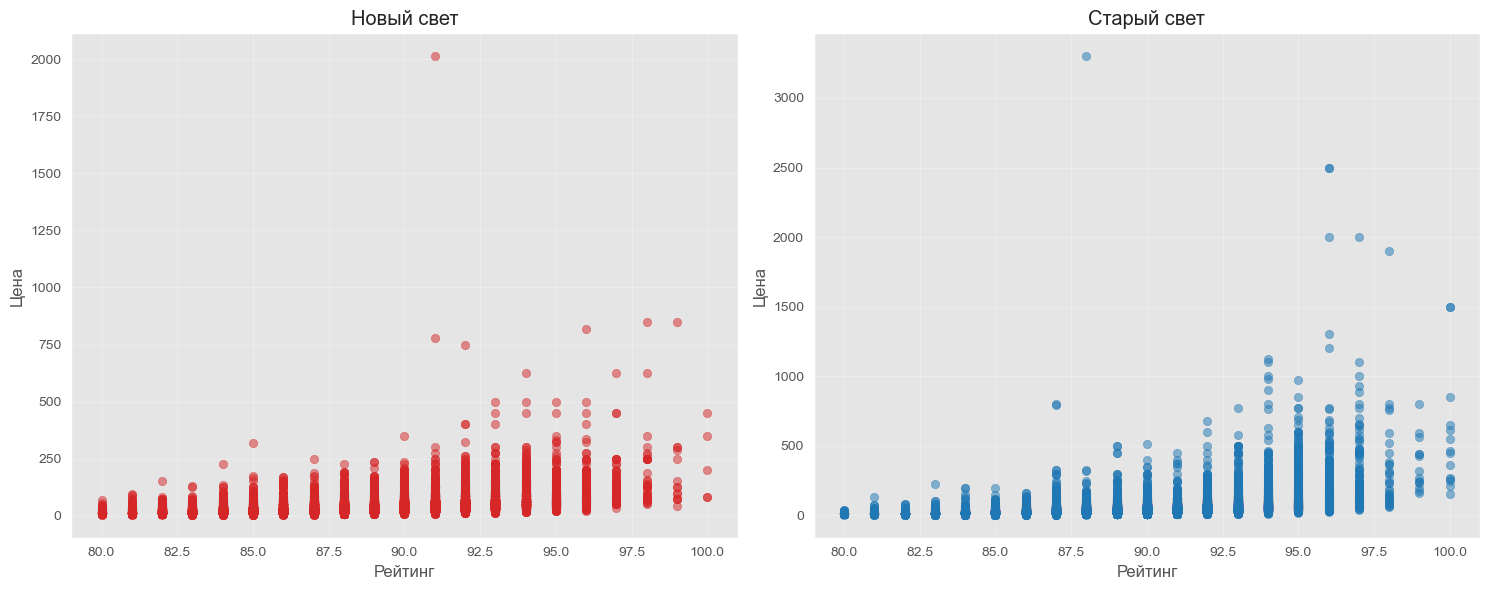

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Новый свет
axes[0].scatter(new_world['points'], new_world['price'], color='#d62728', alpha=0.5)
axes[0].set_title('Новый свет')
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Цена')
axes[0].grid(True, alpha=0.3)

# Старый свет
axes[1].scatter(old_world['points'], old_world['price'], color='#1f77b4', alpha=0.5)
axes[1].set_title('Старый свет')
axes[1].set_xlabel('Рейтинг')
axes[1].set_ylabel('Цена')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
from scipy.stats import pearsonr

# Новый свет
corr_new, p_new = pearsonr(new_world['points'], new_world['price'])
print(f'Новый свет: r = {corr_new:.2f}, p-value = {p_new:.4f}')

# Старый свет
corr_old, p_old = pearsonr(old_world['points'], old_world['price'])
print(f'Старый свет: r = {corr_old:.2f}, p-value = {p_old:.4f}')

Новый свет: r = 0.47, p-value = 0.0000
Старый свет: r = 0.42, p-value = 0.0000


* Коэффициент корреляции Пирсона между ценой и рейтингом составляет 0.47 для Нового света и 0.42 для Старого света (p < 0.001). Это указывает на умеренную положительную связь: вина с более высоким рейтингом в среднем дороже, но зависимость не является строгой — есть исключения как в сторону переоценённых, так и недооценённых вин.

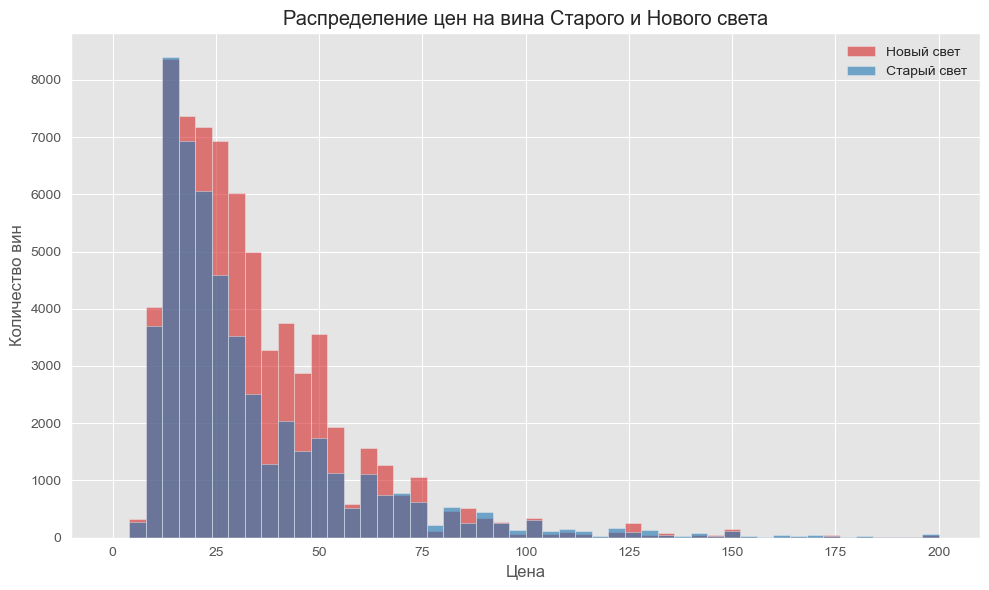

In [136]:
plt.figure(figsize=(10, 6))

# Новый свет
old_new[old_new['age'] == 'new']['price'].hist(
    alpha=0.6, bins=50, range=(0, 200), color='#d62728', label='Новый свет'
)

# Старый свет
old_new[old_new['age'] == 'old']['price'].hist(
    alpha=0.6, bins=50, range=(0, 200), color='#1f77b4', label='Старый свет'
)

plt.xlabel('Цена')
plt.ylabel('Количество вин')
plt.title('Распределение цен на вина Старого и Нового света')
plt.legend(framealpha=0)
plt.tight_layout()
plt.show()

* В Новом свете наблюдается более равномерное распределение цен с заметной долей вин в среднем ценовом сегменте. В Старом свете распределение смещено в сторону дешёвых вин, а количество вин в среднем сегменте существенно ниже, чем в Новом свете.

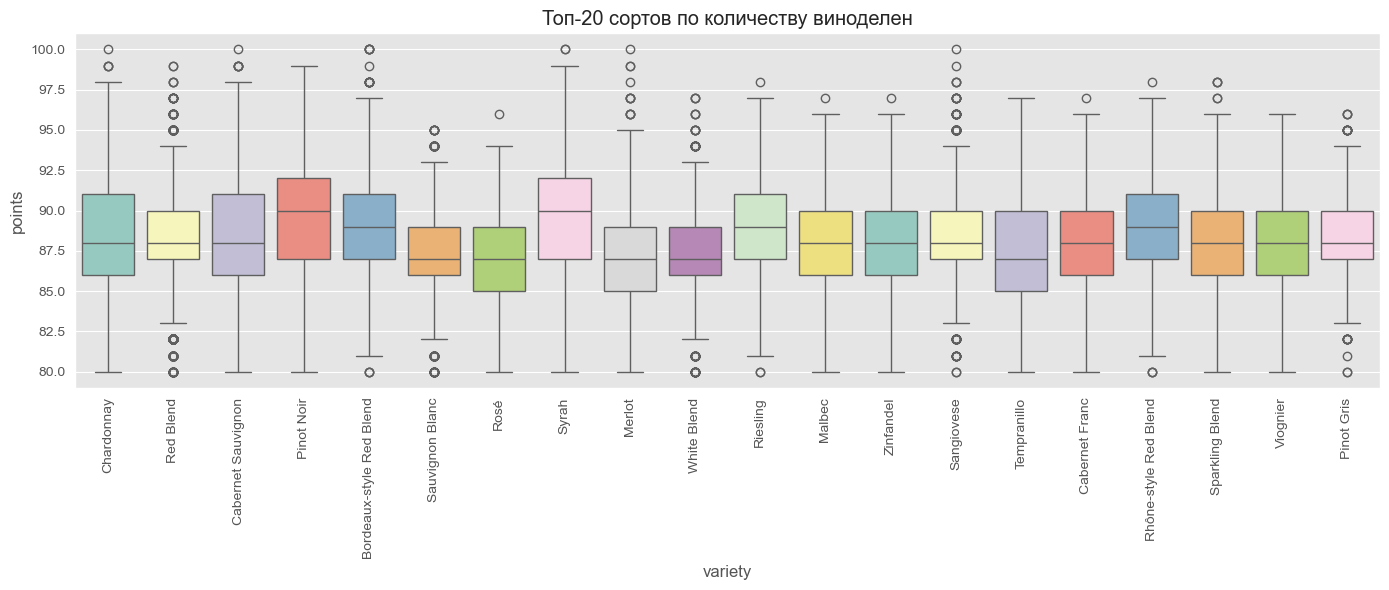

In [119]:
# Топ-20 сортов по количеству виноделен (уникальных)
top20_winery = old_new.groupby('variety')['winery'].nunique().sort_values(ascending=False).head(20).index

# График (рейтинг)
V1 = old_new[old_new['variety'].isin(top20_winery)]
plt.figure(figsize=(14, 6))
sns.boxplot(x='variety', y='points', data=V1, order=top20_winery, palette='Set3')
plt.xticks(rotation=90)
plt.title('Топ-20 сортов по количеству виноделен')
plt.tight_layout()
plt.show()

* у Pinot Gris, Red Blend, Sangiovese, Whight Blend и Savognon Blanc самый короткий размах усов и высота ящика, что говорит о стабильном качестве, хотя есть и редкие аномально хорошие и аномально уступающие по качеству экземпляры.
* в то время как у Pinot Noir, Syrah и Chardonnay качество очень нестабильно и завит от производителя.

In [127]:
# Для каждого сорта и группы считаем средние
comparison = old_new[old_new['variety'].isin(top20_winery)].groupby(['variety', 'age'])[['points', 'price']].mean().round(1)

# Разворачиваем для удобства
comparison_wide = comparison.unstack(level='age')
comparison_wide.columns = ['points_new', 'points_old', 'price_new', 'price_old']
comparison_wide['diff_points'] = comparison_wide['points_new'] - comparison_wide['points_old']
comparison_wide['diff_price'] = comparison_wide['price_new'] - comparison_wide['price_old']

print(comparison_wide.sort_values('diff_points', ascending=False))

                          points_new  points_old  price_new  price_old  \
variety                                                                  
Bordeaux-style Red Blend        89.7        88.2       56.6       40.9   
Sparkling Blend                 88.6        87.7       34.7       26.0   
Cabernet Sauvignon              88.6        87.8       48.3       33.6   
Rhône-style Red Blend           89.4        88.9       36.8       32.9   
Syrah                           89.3        89.2       38.1       49.4   
Rosé                            86.9        86.9       19.3       18.1   
Tempranillo                     87.4        87.6       31.7       31.0   
Pinot Noir                      89.4        89.7       42.9       77.1   
White Blend                     87.0        87.5       21.3       24.4   
Red Blend                       88.0        88.7       34.0       37.5   
Cabernet Franc                  88.0        88.9       34.9       34.5   
Chardonnay                      88.1  

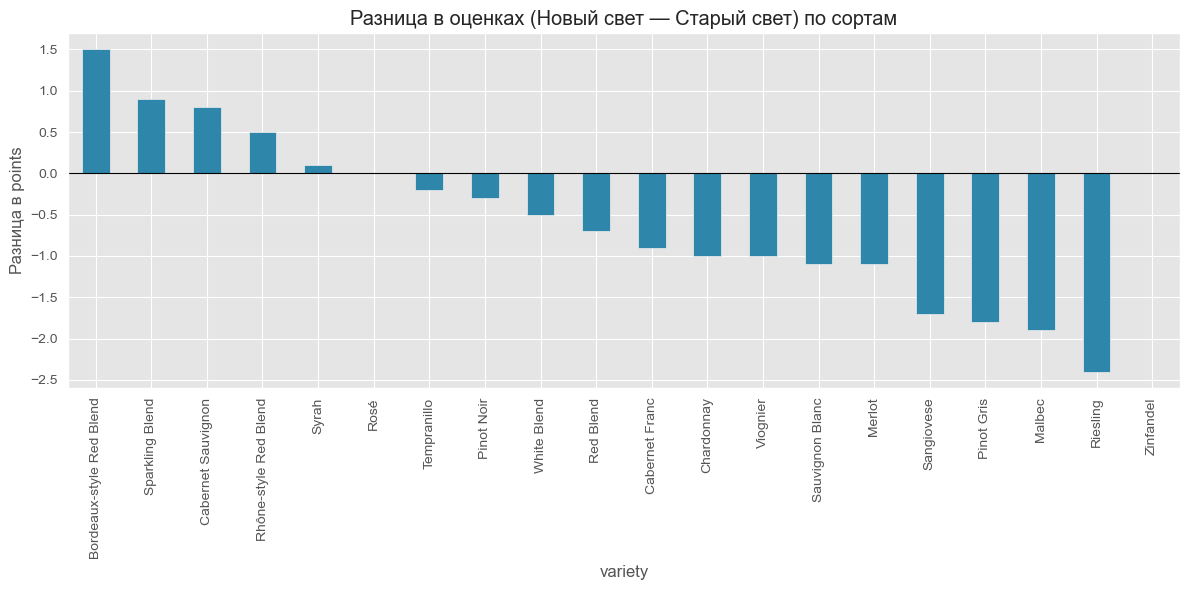

In [128]:
plt.figure(figsize=(12, 6))
comparison_wide.sort_values('diff_points', ascending=False)['diff_points'].plot(kind='bar', color='#2E86AB')
plt.title('Разница в оценках (Новый свет — Старый свет) по сортам')
plt.ylabel('Разница в points')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

* Для топ-20 сортов винограда вина из Старого света в среднем получают более высокие оценки и имеют существенно более высокую цену по сравнению с винами из Нового света того же сорта. Это указывает на то, что регион происхождения является значимым фактором как для воспринимаемого качества, так и для ценообразования.

#  <a name="3">3. Проверка гипотез </a>

## Гипотеза 1
* H0: Средние оценки вин Старого и Нового света одинаковые.
* H1: Средние оценки вин Старого и Нового света разные.


In [143]:
H0 = 'Оценки распрделены нормально'
H1 = 'Оценки распрделены не нормально'
k2, p = st.normaltest(old_new['points'].sample(50))
alpha = 0.01
print("p = {:g}".format(p))

if p < alpha:  # null hypothesis: x comes from a normal distribution
    print(H1)
else:
    print(H0)

p = 0.670632
Оценки распрделены нормально


In [150]:
samplingSize = 1000

old_world_wine = old_new[old_new.age == 'old'].points.sample(samplingSize, random_state=42).sort_values()
new_world_wine = old_new[old_new.age == 'new'].points.sample(samplingSize, random_state=42).sort_values()

In [151]:
test_leven, p = st.levene(old_world_wine, new_world_wine)
print('Statistics=%.3f, p-value=%.3f' % (test_leven, p))
alpha = 0.05
if p < alpha:
    print('Отклонить гипотезу о равенстве дисперсий')
else:
    print('Принять гипотезу о равенстве дисперсий')

Statistics=9.753, p-value=0.002
Отклонить гипотезу о равенстве дисперсий


In [152]:
t,p_value  = st.ttest_ind(old_world_wine,new_world_wine,  equal_var=False)

if p_value < 0.05:
    print(f'Вина Старого и Нового света оценивают неодинаково так как p value - {p_value.round(3)} < 0.05')
else:
    print(f'Вина Старого и Нового света оценивают одинаково так как p value - {p_value.round(3)} > 0.05')

Вина Старого и Нового света оценивают одинаково так как p value - 0.947 > 0.05


* Внутри одного сорта Старый свет даёт более высокие оценки.
* Но в Старом свете есть и другие сорта, которые «тянут» среднюю оценку вниз.
* В Новом свете сорта более однородны по качеству.
* В итоге средние по регионам совпадают.

## Гипотеза 2
* H0: Средние цены вин Старого и Нового света одинаковые.
* H1: Средние цены вин Старого света выше чем Нового.


In [156]:
# Выборки по цене
old_prices = old_new[old_new.age == 'old']['price'].dropna()
new_prices = old_new[old_new.age == 'new']['price'].dropna()

# Односторонний t-test (Старый свет > Новый свет)
t_stat, p_val = st.ttest_ind(old_prices, new_prices, equal_var=False, alternative='greater')

if p_val < 0.05:
    print(f'Цены в Старом свете выше, чем в Новом (p = {p_val:.4f})')
else:
    print(f'Статистически значимых различий в ценах не обнаружено (p = {p_val:.4f})')

Цены в Старом свете выше, чем в Новом (p = 0.0000)


* Односторонний t-test показал, что цены на вина Старого света статистически значимо выше, чем на вина Нового света (p < 0.001).

* Разница в ценах — не случайна.

* Регион происхождения — значимый фактор ценообразования.

* При этом оценки не различаются → значит, премия за Старый свет связана не с объективным качеством (оценками), а с восприятием, традицией, брендом.

#  <a name="4">4. Линейная регрессия </a>

In [158]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Подготовка данных
groups = ['new', 'old']
group_names = ['Новый свет', 'Старый свет']

print('=== Линейная регрессия (цена vs рейтинг) по группам ===\n')

for group, name in zip(groups, group_names):
    data = old_new_drop_price[old_new_drop_price['age'] == group]
    X = data[['points']]
    y = data['price']
    
    # Модель
    linreg = LinearRegression().fit(X, y)
    
    # Коэффициенты
    print(f'--- {name} ---')
    print(f'Коэффициент: {linreg.coef_[0]:.2f}')
    print(f'Свободный член: {linreg.intercept_:.2f}')
    print(f'R²: {linreg.score(X, y):.4f}')
    print(f'Количество наблюдений: {len(X)}')
    print(f'Средняя цена: {y.mean():.2f}')
    print(f'Средний рейтинг: {X["points"].mean():.2f}')
    
    # p-value
    X_const = sm.add_constant(X)
    model_sm = sm.OLS(y, X_const).fit()
    print(f"p-value (points): {model_sm.pvalues['points']:.6f}")
    print()


=== Линейная регрессия (цена vs рейтинг) по группам ===

--- Новый свет ---
Коэффициент: 4.19
Свободный член: -336.12
R²: 0.2239
Количество наблюдений: 69252
Средняя цена: 34.21
Средний рейтинг: 88.30
p-value (points): 0.000000

--- Старый свет ---
Коэффициент: 7.74
Свободный член: -648.59
R²: 0.1768
Количество наблюдений: 51663
Средняя цена: 36.92
Средний рейтинг: 88.59
p-value (points): 0.000000



* В обеих группах наблюдается статистически значимая положительная связь между рейтингом и ценой (p < 0.001). При этом в Новом свете рейтинг объясняет чуть большую долю вариации цен (R² = 0.22 против 0.17 в Старом свете). Это может указывать на то, что в Новом свете рыночная цена в большей степени определяется оценкой качества, чем в Старом свете, где цена, вероятно, сильнее привязана к другим факторам (регион, традиция, бренд)
* Линейная регрессия показывает, что в Старом свете связь между рейтингом и ценой более выражена: рост рейтинга на 1 балл увеличивает цену в среднем на 7,74 доллара, тогда как в Новом свете — только на 4,19 доллара.

# <a name="6">6. Выводы</a>

1. О данных
- Данные содержат оценки вин по шкале 80–100 (средняя 88) и цены от 4 до 3300 долларов (средняя 35, медиана 25).
- Распределение цен имеет правостороннюю асимметрию: основная масса вин сосредоточена в диапазоне 17–42 доллара, а длинный хвост формируют редкие дорогие позиции (до 200+).
- Это указывает на наличие выраженного премиального сегмента, который требует отдельного рассмотрения.

2. Структура рынка
- Лидер по количеству представленных вин — США (около 45% всех наименований), за ними следуют страны Старого света: Франция, Италия, Испания, Португалия.
- В Старом свете на 12% больше виноделен и на 40% больше различных сортов винограда, чем в Новом свете.
- При этом в Новом свете на 50% больше различных наименований в портфеле одного производителя.
- Это говорит о том, что производители Нового света ориентированы на массовые, проверенные рынком сорта, тогда как Старый свет делает ставку на локальные, уникальные марки.

3. Различия между регионами (Старый vs Новый свет)<br>
<br>
По ценам:
- Вина Старого света статистически значимо дороже (p < 0.001).
- Средняя цена выше, и в Старом свете присутствует больше дорогих позиций (до 750 долларов).
- В Новом свете основная масса вин сосредоточена в сегменте до 300 долларов.<br>
<br>
По оценкам:
- Средние оценки вин Старого и Нового света не различаются статистически (p = 0.947).
- Однако на уровне отдельных сортов (например, Pinot Noir, Chardonnay) вина Старого света получают более высокие оценки.
- В Старом свете разброс оценок шире, в Новом свете — более однороден.<br>
<br>
По сортам:
- Топ-20 сортов по числу производителей отличаются в регионах.
- В Старом свете много локальных сортов, в Новом — массовые, международные.
- На уровне топ-20 сортов вина Старого света имеют более высокие оценки и цены.

4. Связь цены и качества
- Корреляция Пирсона между ценой и рейтингом умеренная: Новый свет — r = 0.47, Старый свет — r = 0.42 (p < 0.001).
- Линейная регрессия показывает, что в Старом свете рейтинг сильнее влияет на цену: рост рейтинга на 1 балл увеличивает цену на 7.74 доллара, в Новом свете — на 4.19 доллара.
- При этом в Новом свете связь более стабильна (R² = 0.22 против 0.17 в Старом свете), что может указывать на большее влияние других факторов (регион, бренд, традиция) в Старом свете.

5. Итоговый вывод
- Разница в ценах между Старым и Новым светом статистически значима и не объясняется объективным качеством (оценками).
- Премия за вина Старого света связана не с более высокими оценками, а с регионом, традицией, восприятием и брендом.
- В Старом свете рынок более фрагментирован: много мелких производителей, локальных сортов и широкий ценовой разброс.
- В Новом свете рынок более концентрирован: меньше производителей, больше массовых сортов, цены более предсказуемы и сильнее привязаны к рейтингу.

Рекомендации
- Премиальный сегмент (цены > 200 долларов) требует отдельного анализа.
- Для производителей из Нового света важна стратегия ценообразования, основанная на рейтингах, тогда как для производителей Старого света ключевым активом остаётся региональный бренд.